In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

# Load model and data
model   = joblib.load('../models/xgboost_final_model.pkl')
scaler  = joblib.load('../models/scaler.pkl')

X_test  = pd.read_csv('../data/X_test.csv')
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

print("✅ Model and data loaded!")
print(f"Test samples : {X_test.shape[0]}")
print(f"Features     : {X_test.shape[1]}")

C:\Users\marri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Model and data loaded!
Test samples : 330
Features     : 18


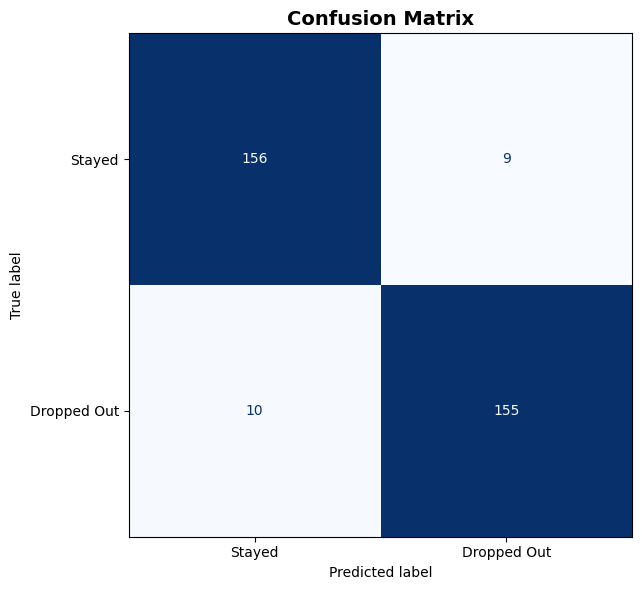


True Negatives  (Stayed, predicted Stayed)      : 156
False Positives (Stayed, predicted Dropped Out) : 9
False Negatives (Dropped Out, predicted Stayed) : 10  ← we want this LOW
True Positives  (Dropped Out, predicted Dropped): 155


In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Dropped Out']
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()

# Print the numbers clearly
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Stayed, predicted Stayed)      : {tn}")
print(f"False Positives (Stayed, predicted Dropped Out) : {fp}")
print(f"False Negatives (Dropped Out, predicted Stayed) : {fn}  ← we want this LOW")
print(f"True Positives  (Dropped Out, predicted Dropped): {tp}")

In [3]:
from sklearn.metrics import classification_report

print("Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Dropped Out']))

Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

      Stayed       0.94      0.95      0.94       165
 Dropped Out       0.95      0.94      0.94       165

    accuracy                           0.94       330
   macro avg       0.94      0.94      0.94       330
weighted avg       0.94      0.94      0.94       330



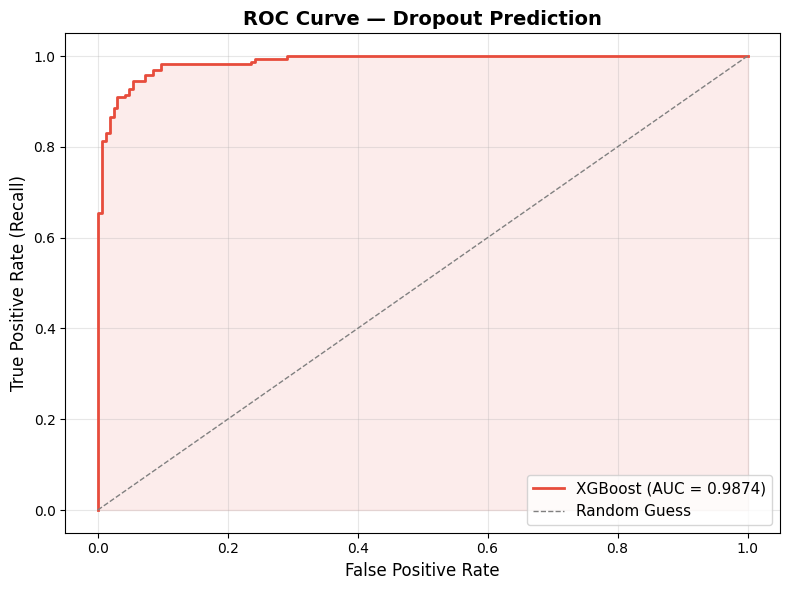

✅ AUC-ROC Score: 0.9874


In [4]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random Guess')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Dropout Prediction', fontsize=14,
          fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png', dpi=150)
plt.show()
print(f"✅ AUC-ROC Score: {auc_score:.4f}")

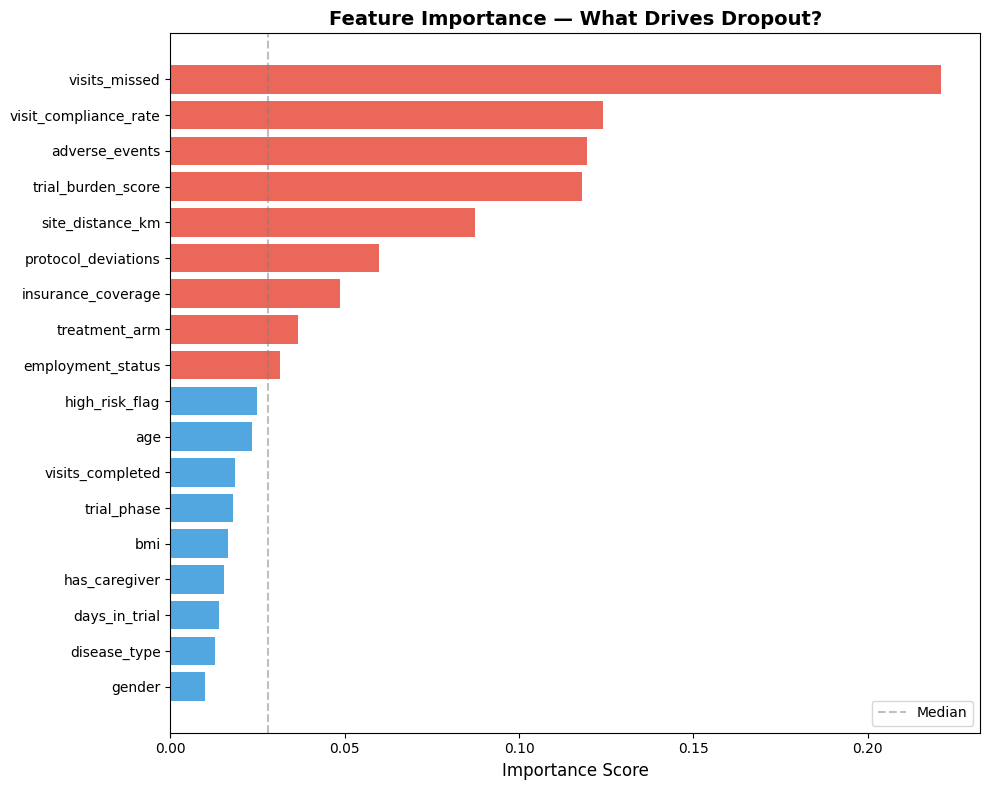

In [5]:
importance_df = pd.DataFrame({
    'Feature'   : X_test.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > importance_df['Importance'].median()
          else '#3498db' for x in importance_df['Importance']]
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors, alpha=0.85)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — What Drives Dropout?',
          fontsize=14, fontweight='bold')
plt.axvline(importance_df['Importance'].median(),
            color='gray', linestyle='--', alpha=0.5,
            label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

In [6]:
# Create SHAP explainer
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values computed!")
print(f"SHAP values shape: {shap_values.shape}")

✅ SHAP values computed!
SHAP values shape: (330, 18)


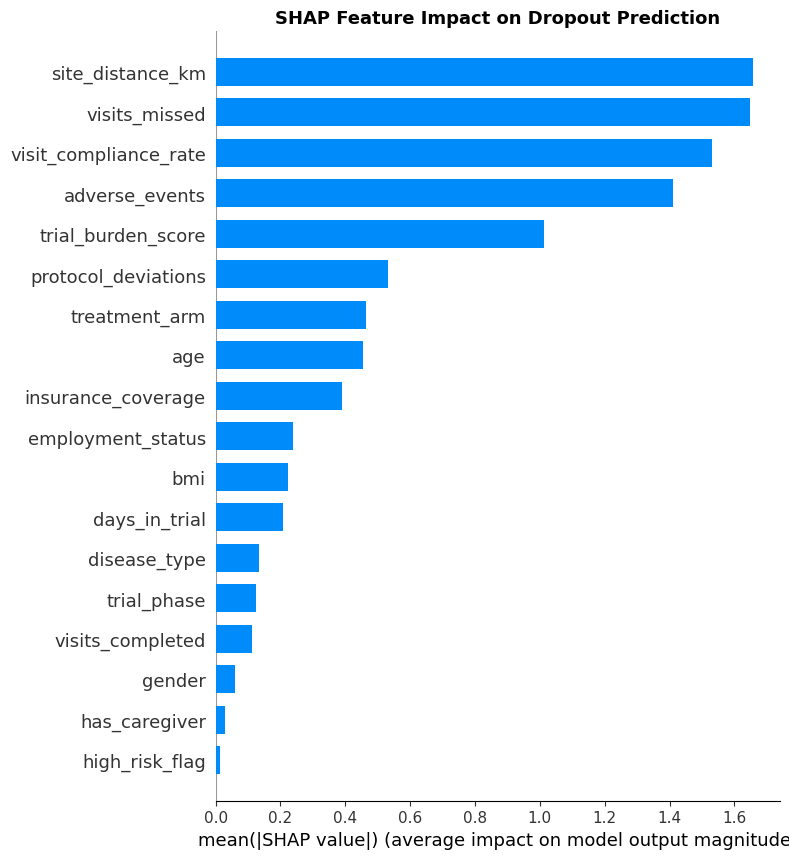

In [7]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Impact on Dropout Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_summary_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

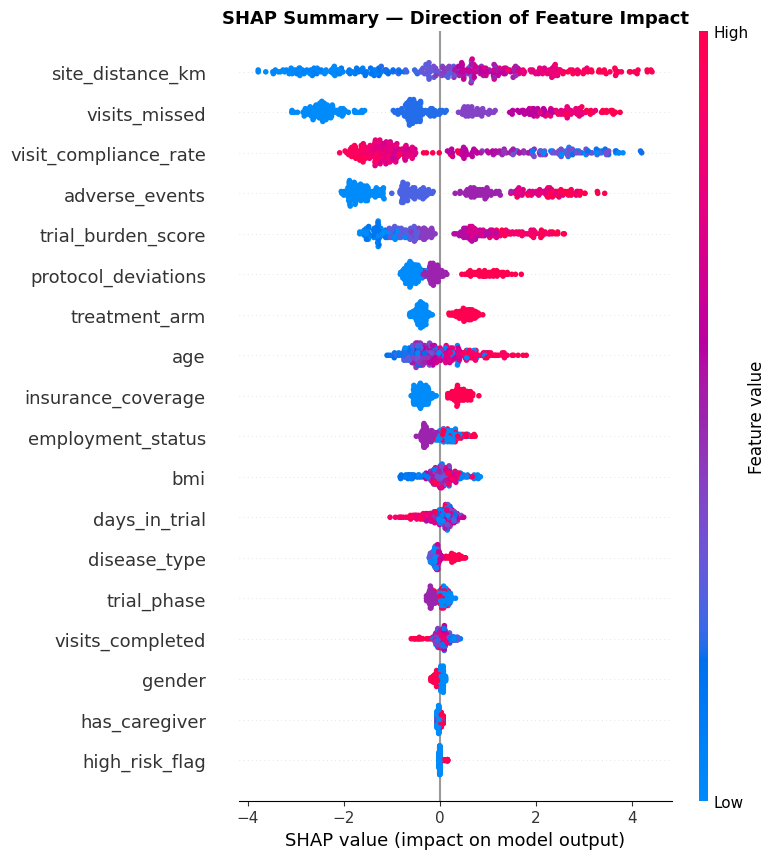

In [8]:
# This shows not just importance but WHETHER high/low values
# push toward dropout or staying
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title('SHAP Summary — Direction of Feature Impact',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_summary_dot.png',
            dpi=150, bbox_inches='tight')
plt.show()

Patient 0 Details:
  Actual outcome    : Stayed
  Predicted dropout risk: 0.1%



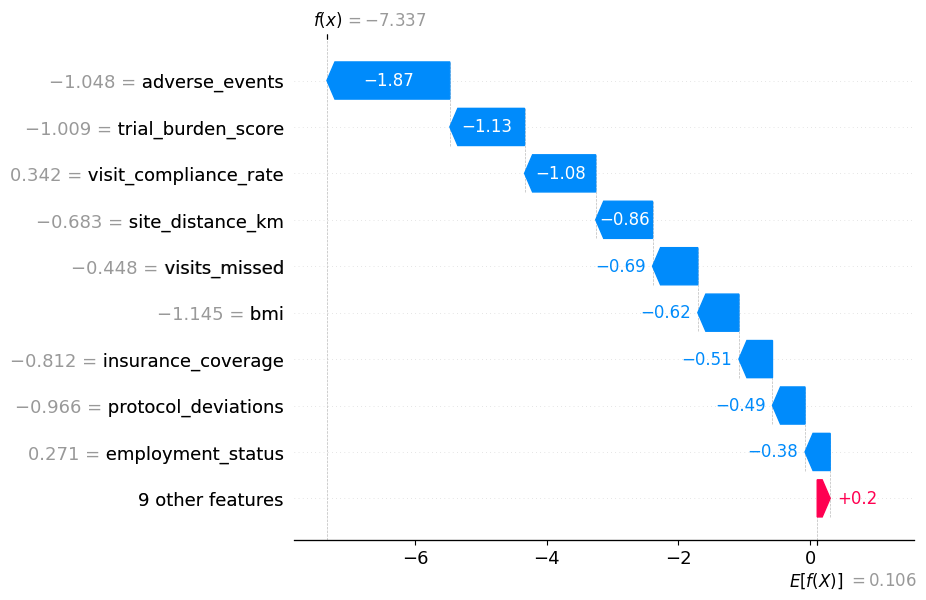

<Figure size 640x480 with 0 Axes>

In [9]:
# Pick patient at index 0 from test set
patient_index = 0
patient_data  = X_test.iloc[[patient_index]]
actual_label  = y_test[patient_index]
predicted_prob = model.predict_proba(patient_data)[0][1]

print(f"Patient {patient_index} Details:")
print(f"  Actual outcome    : {'Dropped Out' if actual_label == 1 else 'Stayed'}")
print(f"  Predicted dropout risk: {predicted_prob*100:.1f}%")
print()

# SHAP waterfall plot — shows exactly WHY this prediction was made
shap.plots.waterfall(
    shap.Explanation(
        values         = shap_values[patient_index],
        base_values    = explainer.expected_value,
        data           = X_test.iloc[patient_index],
        feature_names  = X_test.columns.tolist()
    )
)
plt.savefig('../outputs/shap_waterfall_patient0.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Generate risk scores for all test patients
risk_scores = model.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    'patient_index'   : range(len(X_test)),
    'dropout_risk_%'  : (risk_scores * 100).round(1),
    'actual_outcome'  : ['Dropped Out' if y == 1 else 'Stayed'
                         for y in y_test],
    'risk_level'      : pd.cut(
                            risk_scores,
                            bins   =[0, 0.33, 0.66, 1.0],
                            labels =['🟢 Low', '🟡 Medium', '🔴 High']
                        )
})

# Sort by highest risk first
risk_df = risk_df.sort_values('dropout_risk_%', ascending=False)

print("Top 10 Highest Risk Patients:")
print(risk_df.head(10).to_string(index=False))

# Save it
risk_df.to_csv('../outputs/patient_risk_scores.csv', index=False)
print("\n✅ Risk scores saved to outputs/patient_risk_scores.csv")

Top 10 Highest Risk Patients:
 patient_index  dropout_risk_% actual_outcome risk_level
           303           100.0    Dropped Out     🔴 High
            30           100.0    Dropped Out     🔴 High
           292           100.0    Dropped Out     🔴 High
            21           100.0    Dropped Out     🔴 High
            19           100.0    Dropped Out     🔴 High
           285           100.0    Dropped Out     🔴 High
           286           100.0    Dropped Out     🔴 High
            39           100.0    Dropped Out     🔴 High
           275           100.0    Dropped Out     🔴 High
           171           100.0    Dropped Out     🔴 High

✅ Risk scores saved to outputs/patient_risk_scores.csv
